## Importing All Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## Importing Datasets

In [2]:
dataset_1 = pd.read_csv("emotion_dataset_raw.csv")
dataset_2 = pd.read_csv("combined_emotion.csv")

In [3]:
print(dataset_1.shape)
print(dataset_2.shape)

(34792, 2)
(422746, 2)


In [4]:
print("Dataset 1: ", dataset_1)
print("Dataset 2: ", dataset_2)

Dataset 1:          Emotion                                               Text
0       neutral                                             Why ? 
1           joy    Sage Act upgrade on my to do list for tommorow.
2       sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3           joy   Such an eye ! The true hazel eye-and so brill...
4           joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
...         ...                                                ...
34787  surprise  @MichelGW have you gift! Hope you like it! It'...
34788       joy  The world didnt give it to me..so the world MO...
34789     anger                           A man robbed me today . 
34790      fear  Youu call it JEALOUSY, I call it of #Losing YO...
34791   sadness  I think about you baby, and I dream about you ...

[34792 rows x 2 columns]
Dataset 2:                                                   sentence emotion
0           i just feel really helpless and heavy hearted    fear
1       ive en

In [5]:
print(len(dataset_1))
print(len(dataset_2))

34792
422746


In [6]:
print(dataset_1.head(5000).to_string())

       Emotion                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            Text
0      neutral                                                                                                                                                                                                                                                                                                                                                                                                                                                           

## Imporitng Libraries to preprocess data

In [7]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sam\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sam\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

## Dataset_1

In [8]:
copy_d1 = dataset_1.copy()

In [9]:
print(copy_d1)

        Emotion                                               Text
0       neutral                                             Why ? 
1           joy    Sage Act upgrade on my to do list for tommorow.
2       sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3           joy   Such an eye ! The true hazel eye-and so brill...
4           joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
...         ...                                                ...
34787  surprise  @MichelGW have you gift! Hope you like it! It'...
34788       joy  The world didnt give it to me..so the world MO...
34789     anger                           A man robbed me today . 
34790      fear  Youu call it JEALOUSY, I call it of #Losing YO...
34791   sadness  I think about you baby, and I dream about you ...

[34792 rows x 2 columns]


In [10]:
duplicates = copy_d1['Text'].duplicated()
print(duplicates)

0        False
1        False
2        False
3        False
4        False
         ...  
34787    False
34788    False
34789    False
34790    False
34791    False
Name: Text, Length: 34792, dtype: bool


In [11]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

3682


In [12]:
copy_d1 = copy_d1.drop_duplicates(subset=['Text'])
print(copy_d1)

        Emotion                                               Text
0       neutral                                             Why ? 
1           joy    Sage Act upgrade on my to do list for tommorow.
2       sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3           joy   Such an eye ! The true hazel eye-and so brill...
4           joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
...         ...                                                ...
34787  surprise  @MichelGW have you gift! Hope you like it! It'...
34788       joy  The world didnt give it to me..so the world MO...
34789     anger                           A man robbed me today . 
34790      fear  Youu call it JEALOUSY, I call it of #Losing YO...
34791   sadness  I think about you baby, and I dream about you ...

[31110 rows x 2 columns]


In [13]:
has_nan = copy_d1[['Text', 'Emotion']].isna().any()
print(has_nan)

Text       False
Emotion    False
dtype: bool


In [14]:

mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()  
print(mask)
mask = copy_d1['Text'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d1['Text'].str.isascii()
print(mask.sum())

1454
5068
4267
2119
1421


In [15]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
HTML_TAGS = re.compile(r'\b(href|http|https|www|html|amp|nbsp)\w*\b')

def preprocess_1(text):
    text = text.lower()
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'&\w+', '', text)
    text = HTML_TAGS.sub(' ', text)   
    text = text.encode('ascii', 'ignore').decode('ascii')    
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)    
    text = re.sub(r'\s+', ' ', text).strip()    
    tokens = word_tokenize(text)    
    tokens = [t for t in tokens if t not in stop_words]    
    tokens = [stemmer.stem(t) for t in tokens]    
    return ' '.join(tokens)

In [16]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Sam\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [17]:
copy_d1['Text'] = copy_d1['Text'].apply(preprocess_1)
print("done")

done


In [18]:
mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()  
print(mask)
mask = copy_d1['Text'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d1['Text'].str.isascii()
print(mask.sum())

316
0
0
0
0


In [19]:
print(copy_d1['Text'].isnull().sum())

print((copy_d1['Text'] == '').sum())

print(copy_d1[copy_d1['Text'] == ''])

copy_d1 = copy_d1[copy_d1['Text'] != '']
copy_d1 = copy_d1.reset_index(drop=True)

0
149
       Emotion Text
0      neutral     
76     neutral     
114    neutral     
269    neutral     
392    neutral     
...        ...  ...
34000  neutral     
34234  neutral     
34243  neutral     
34429  neutral     
34662  neutral     

[149 rows x 2 columns]


In [20]:
print((copy_d1['Text'] == '').sum())

0


In [21]:
mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)

316


In [22]:
print("Original Dataset: " ,dataset_1.head(10))
print("Processed Dataset: " ,copy_d1.head(10))

Original Dataset:      Emotion                                               Text
0   neutral                                             Why ? 
1       joy    Sage Act upgrade on my to do list for tommorow.
2   sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3       joy   Such an eye ! The true hazel eye-and so brill...
4       joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
5      fear  I'm expecting an extremely important phonecall...
6   sadness   .Couldnt wait to see them live. If missing th...
7  surprise  maken Tip 2: Stop op een moment dat je het hel...
8  surprise  En dan krijg je ff een cadeautje van een tweep...
9  surprise   @1116am Drummer Boy bij op verzoek van @BiemO...
Processed Dataset:      Emotion                                               Text
0       joy                      sage act upgrad list tommorow
1   sadness  way homegirl babi funer man hate funer realli ...
2       joy  eye true hazel eyeand brilliant regular featur...
3       joy  ugh

In [23]:
print(copy_d1.shape)

(30961, 2)


In [24]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

678


In [25]:
copy_d1 = copy_d1.drop_duplicates(subset=['Text'])

In [26]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

0


In [27]:
contraction_pattern = r"'t|'s|'m|'d|'re|'ve|'ll"
mask_contractions = copy_d1['Text'].str.contains(contraction_pattern, regex=True, na=False)
print(f"Rows with contractions: {mask_contractions.sum()}")

Rows with contractions: 0


In [28]:
print(copy_d1.shape)

(30283, 2)


## Dataset_2

In [29]:
copy_d2 = dataset_2.copy()

In [30]:
print(copy_d2)

                                                 sentence emotion
0           i just feel really helpless and heavy hearted    fear
1       ive enjoyed being able to slouch about relax a...     sad
2       i gave up my internship with the dmrg and am f...    fear
3                              i dont know i feel so lost     sad
4       i am a kindergarten teacher and i am thoroughl...    fear
...                                                   ...     ...
422741                 i begun to feel distressed for you    fear
422742  i left feeling annoyed and angry thinking that...   anger
422743  i were to ever get married i d have everything...     joy
422744  i feel reluctant in applying there because i w...    fear
422745  i just wanted to apologize to you because i fe...   anger

[422746 rows x 2 columns]


In [31]:
duplicates = copy_d2['sentence'].duplicated()
print(duplicates)

0         False
1         False
2         False
3         False
4         False
          ...  
422741     True
422742     True
422743     True
422744     True
422745     True
Name: sentence, Length: 422746, dtype: bool


In [32]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

28924


In [33]:
copy_d2 = copy_d2.drop_duplicates(subset=['sentence'])

In [34]:
has_nan = copy_d2[['sentence', 'emotion']].isna().any()
print(has_nan)

sentence    False
emotion     False
dtype: bool


In [35]:
mask = copy_d2['sentence'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d2['sentence'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()  
print(mask)
mask = copy_d2['sentence'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d2['sentence'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d2['sentence'].str.isascii()
print(mask.sum())

9244
0
0
0
0


In [36]:
contraction_pattern = r"'t|'s|'m|'d|'re|'ve|'ll"
mask_contractions = copy_d2['sentence'].str.contains(contraction_pattern, regex=True, na=False)
print(f"Rows with contractions: {mask_contractions.sum()}")

Rows with contractions: 0


In [37]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
HTML_TAGS = re.compile(r'\b(href|http|https|www|html|amp|nbsp)\w*\b')

def preprocess_2(text):
    text = text.lower()
    text = HTML_TAGS.sub(' ', text)       
    text = text.translate(str.maketrans('', '', string.punctuation))    
    text = re.sub(r'\d+', '', text)    
    text = re.sub(r'\s+', ' ', text).strip()    
    tokens = word_tokenize(text)    
    tokens = [t for t in tokens if t not in stop_words]    
    tokens = [stemmer.stem(t) for t in tokens]    
    return ' '.join(tokens)

In [38]:
copy_d2['sentence'] = copy_d2['sentence'].apply(preprocess_2)
print("done")

done


In [39]:
mask = copy_d2['sentence'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)

2008


In [40]:
print(copy_d2['sentence'].isnull().sum())

print((copy_d2['sentence'] == '').sum())


0
9


In [41]:
copy_d2 = copy_d2[copy_d2['sentence'] != '']
copy_d2 = copy_d2.reset_index(drop=True)

In [42]:
print((copy_d2['sentence'] == '').sum())

0


In [43]:
print("Original Dataset: " ,dataset_2.head(10))
print("Processed Dataset: " ,copy_d2.head(10))

Original Dataset:                                              sentence  emotion
0      i just feel really helpless and heavy hearted     fear
1  ive enjoyed being able to slouch about relax a...      sad
2  i gave up my internship with the dmrg and am f...     fear
3                         i dont know i feel so lost      sad
4  i am a kindergarten teacher and i am thoroughl...     fear
5         i was beginning to feel quite disheartened      sad
6  i would think that whomever would be lucky eno...     love
7  i fear that they won t ever feel that deliciou...      joy
8  im forever taking some time out to have a lie ...  suprise
9  i can still lose the weight without feeling de...      sad
Processed Dataset:                                              sentence  emotion
0                   feel realli helpless heavi heart     fear
1  ive enjoy abl slouch relax unwind frankli need...      sad
2               gave internship dmrg feel distraught     fear
3                              

In [44]:
print(copy_d2.shape)

(393813, 2)


In [45]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

14002


In [46]:
copy_d2 = copy_d2.drop_duplicates(subset=['sentence'])

In [47]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

0


In [48]:
print(copy_d2.shape)

(379811, 2)


In [49]:
copy_d1.to_csv('emotion_dataset_1.csv', index = False)
copy_d2.to_csv('emotion_dataset_2.csv', index = False)

# Splitting train(80%)-test(20%)

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
x = copy_d1["Text"]
y = copy_d1["Emotion"]

In [74]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

# Bag of Words

In [87]:
bow = CountVectorizer()
x_train_bow = bow.fit_transform(x_train)
x_test_bow = bow.transform(x_test)

# TF-IDF

In [ ]:
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

# Linear Support Vector Classifier(SVC)

In [88]:
svc = LinearSVC(random_state=42)

In [89]:
svc.fit(x_train_bow, y_train)
svc.fit(x_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [90]:
y_pred_bow = svc.predict(x_test_bow)
y_pred_tfidf = svc.predict(x_test_tfidf)

# Evaluation

In [92]:
accuracy_bow = accuracy_score(y_test, y_pred_bow)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

In [93]:
precision_bow = precision_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
precision_tfidf = precision_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [94]:
recall_bow = recall_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
recall_tfidf = recall_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [95]:
f1_bow = f1_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
f1_tfidf = f1_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [98]:
print("Using Bag of Words:")
print(f"Accuracy:{accuracy_bow:.2%}")
print(f"Precision:{precision_bow:.2%}")
print(f"Recall:{recall_bow:.2%}")
print(f"F1-Score:{f1_bow:.2%}")
print("\nUsing TF-IDF:")
print(f"Accuracy:{accuracy_tfidf:.2%}")
print(f"Precision:{precision_tfidf:.2%}")
print(f"Recall:{recall_tfidf:.2%}")
print(f"F1-Score:{f1_tfidf:.2%}")

Using Bag of Words:
Accuracy:58.38%
Precision:57.91%
Recall:58.38%
F1-Score:57.87%

Using TF-IDF:
Accuracy:58.11%
Precision:57.34%
Recall:58.11%
F1-Score:57.11%


In [102]:
print("Using Bag of Words:")
print(classification_report(y_test, y_pred_bow))
print("\nUsing TF-IDF:")
print(classification_report(y_test, y_pred_tfidf))

Using Bag of Words:
              precision    recall  f1-score   support

       anger       0.54      0.55      0.54       744
     disgust       0.39      0.34      0.36       171
        fear       0.61      0.60      0.60       807
         joy       0.66      0.70      0.68      2063
     neutral       0.46      0.18      0.25       222
     sadness       0.55      0.56      0.56      1222
       shame       0.93      0.90      0.91        29
    surprise       0.48      0.48      0.48       799

    accuracy                           0.58      6057
   macro avg       0.58      0.54      0.55      6057
weighted avg       0.58      0.58      0.58      6057


Using TF-IDF:
              precision    recall  f1-score   support

       anger       0.57      0.51      0.54       744
     disgust       0.49      0.22      0.31       171
        fear       0.65      0.57      0.60       807
         joy       0.61      0.75      0.67      2063
     neutral       0.39      0.18      0.24

# Confusion Matrix

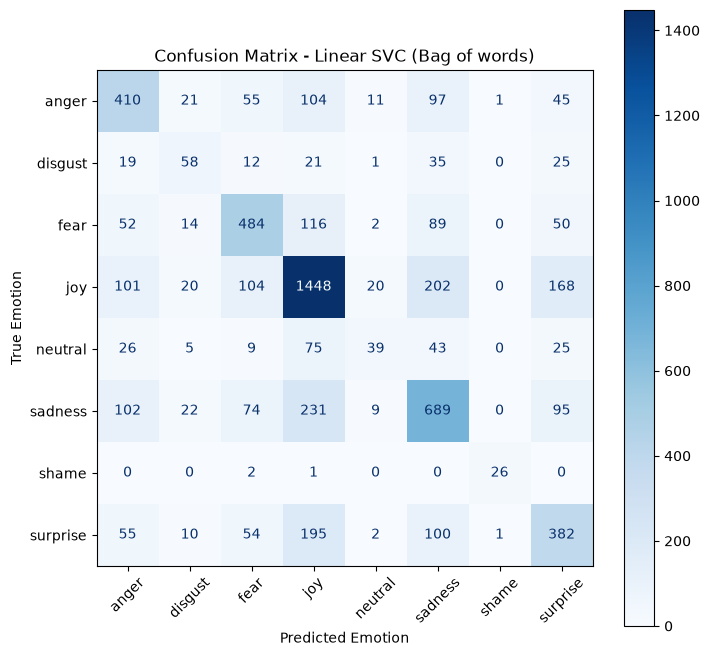

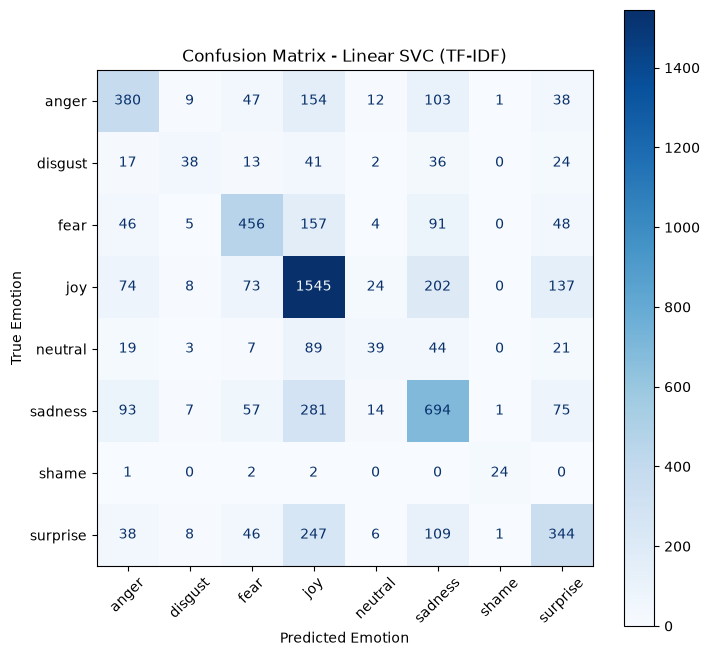

In [104]:
emo_labels = sorted(copy_d1["Emotion"].unique())
cm_bow = confusion_matrix(y_test, y_pred_bow, labels=emo_labels)
disp_bow = ConfusionMatrixDisplay(confusion_matrix=cm_bow, display_labels=emo_labels)
fig, ax = plt.subplots(figsize = (8, 8))
disp_bow.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Linear SVC (Bag of words)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

cm_tfidf = confusion_matrix(y_test, y_pred_tfidf, labels=emo_labels)
disp_tfidf = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf, display_labels=emo_labels)
fig, ax = plt.subplots(figsize=(8, 8))
disp_tfidf.plot(ax = ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Linear SVC (TF-IDF)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()